# Credit Risk Analysis

## Intrroducción

Este tutorial muestra cómo se pueden utilizar algoritmos cuánticos para analisis de riesgos en créditos. De manera más precisa, cómo el Quantum Amplitude Estimation (QAE) puede utilizarse para estimar medidas de riesgos con una velocidad cuadráticamente mayor que las simulaciones clásicas por Monte Carlo.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumRegister, QuantumCircuit
from qiskit.circuit.library import IntegerComparator
from qiskit_algorithms import IterativeAmplitudeEstimation, EstimationProblem
from qiskit_aer.primitives import Sampler

## Definición del problema

En este tutorial queremos analizar el riesgo de un crédito de un portfolio de $K$ activos. La probablidad por defecto de cada activo $k$ sigue un modelo de independencia gaussiana condicional, es decir, dado un valor $z$ escogido aleatoriamente de la variable $Z$ siguiendo una distribución normal, la probabilidad por defecto del activo *k* viene dada por:
$$p_k(z) = F\left( \frac{F^{-1}(p_k^0) - \sqrt{\rho_k}z}{\sqrt{1 - \rho_k}} \right)$$
Donde $F$ denota la función de distribución acumulada de $Z$, $p^0_k$ es la probabilidad por defecto del activo $k$ para $z = 0 $ y $\rho_k$ es la sensibilidad de la probabilidad por defecto del activo $k$ respecto $Z$. Entonces, dado un $Z$ concreto, los eventos individuales por defecto se asumen independientes entre ellos.

Estamos interesados en analizar las medidas de riesgo de la pérdida total:
$$ L = \sum_{k=1}^K \lambda_k X_k(Z) $$

Donde $\lambda_k$ denota la pérdida dada por defecto del activo $k$ y , dado $Z$, $X_k(Z)$ denota una variable Bernoulli que representa el evento por defecto del activo $k$. De manera más precisa, estamos interesados en el valor esperado $\mathbb{E}[L]$, el VaR de $L$ y el CVaR, donde se define tanto el VaR como el CVaR como:
$$ \text{VaR}_{\alpha}(L) = \inf \{ x \mid \mathbb{P}[L <= x] \geq 1 - \alpha \} $$
con un nivel de confianza $ \alpha \in [0, 1] $, y 
$$ \text{CVaR}_{\alpha}(L) = \mathbb{E}[ L \mid L \geq \text{VaR}_{\alpha}(L) ] $$

El problema se define por los siguientes parámetros:

*  Número de qubits utilizados para representar $Z$, denotado por $n_Z$

*  Valor de truncación para $Z$, denotado por $z_{max}$, es decir, asumiendo que Z toma $2^{n_Z}$ valores equidistantes entre $\{-z_{max}, ..., +z_{max}\}$

*  Las probabilidades por defecto para cada activo $p_0^k \in (0, 1)$

*  Las sensibilidades de las probabilidades por defecto con respecto a $Z$, denotadas por $ \rho_k \in [0, 1)$

*  La pérdida por defecto dada para cada activo $k$, denotada por $\lambda_k$

*  Nivel de confianza para VaR y CVar, dado por $\alpha \in [0, 1]$


In [2]:
#Definición de los parámetros del problema.
n_z = 2
z_max = 2
z_values = np.linspace(-z_max, z_max, 2**n_z)
p_zeros = [0.15, 0.25]
rhos = [0.1, 0.05]
lgd = [1,2]
K = len(p_zeros)
alpha = 0.05

# Modelo de incertidumbre

Construimos ahora un circuito que carga el modelo de incertidumbre. Esto se consigue creando un estado cuántico en un registro de $n_z$ qubits que representan $Z$ siguiendo una distribución normal estándar. Este estado se utiliza después para controlar rotaciones en el eje Y de un solo qubit en un registro de $K$ qubits, donde el estado $\ket{1}$ del qubit $k$ representa el evento por defecto del activo $k$. El estado resultante puede escribirse como:
$$ |\Psi\rangle = \sum_{i=0}^{2^{n_z}-1} \sqrt{p_z^i} |z_i \rangle \bigotimes_{k=1}^K
\left( \sqrt{1 - p_k(z_i)}|0\rangle + \sqrt{p_k(z_i)}|1\rangle\right), $$
donde se denota con $z_i$ el i-ésimo valor de $Z$ discretizado y truncado.

In [3]:
from qiskit_finance.circuit.library import GaussianConditionalIndependenceModel as GCI

u = GCI(n_z, z_max, p_zeros, rhos)
u.draw()

┌───────┐
q_0: ┤0      ├
     │       │
q_1: ┤1      ├
     │  P(X) │
q_2: ┤2      ├
     │       │
q_3: ┤3      ├
     └───────┘

Utilizamos ahora el smulador para validar el circuito que contruye $\ket{\Psi}$ y computar los correspondientes valor exactos para
*  Pérdida esperada $\mathbb{E}[L]$
*  PDF y CDF de $L$
*  VaR y la correspondiente probabilidad
*  CVaR

In [4]:
u_measure = u.measure_all(inplace = False)
sampler = Sampler()
job = sampler.run(u_measure)
binary_probabilities = job.result().quasi_dists[0].binary_probabilities()

In [5]:
#Analizar circuito de incertidumbre y determinar las soluciones exactas
p_z = np.zeros(2**n_z)
p_default = np.zeros(K)
values = []
probabilities = []
num_qubits = u.num_qubits

for i, prob in binary_probabilities.items():
    #Extraer el valor de Z y la probabilidad correspondiente
    i_normal = int(i[-n_z:],2)
    p_z[i_normal] += prob

    #Determinar la probabilidad total por defecto para k
    loss = 0
    for k in range(K):
        if i[K - k - 1] == "1":
            p_default[k] += prob
            loss += lgd[k]
    values += [loss]
    probabilities += [prob]
values = np.array(values)
probabilities = np.array(probabilities)

expected_loss= np.dot(values, probabilities)
losses = np.sort(np.unique(values))
pdf = np.zeros(len(losses))
for i, v in enumerate(losses):
    pdf[i] += sum(probabilities[values == v])
cdf = np.cumsum(pdf)

i_var = np.argmax(cdf >= 1 - alpha)
exact_var = losses[i_var]
exact_cvar = np.dot(pdf[(i_var + 1) :], losses[(i_var + 1) :]) / sum(pdf[(i_var + 1) :])

In [6]:
print("Expected Loss E[L]:                %.4f" % expected_loss)
print("Value at Risk VaR[L]:              %.4f" % exact_var)
print("P[L <= VaR[L]]:                    %.4f" % cdf[exact_var])
print("Conditional Value at Risk CVaR[L]: %.4f" % exact_cvar)

Expected Loss E[L]:                0.5986
Value at Risk VaR[L]:              2.0000
P[L <= VaR[L]]:                    0.9619
Conditional Value at Risk CVaR[L]: 3.0000


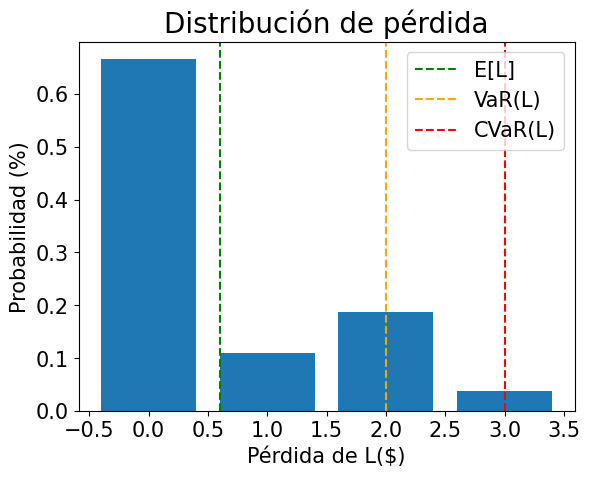

In [7]:
#Graficar loss PDF, pérdida esperada, VaR y CVar
plt.bar(losses, pdf)
plt.axvline(expected_loss, color="green", linestyle="--", label="E[L]")
plt.axvline(exact_var, color="orange", linestyle="--", label="VaR(L)")
plt.axvline(exact_cvar, color="red", linestyle="--", label="CVaR(L)")
plt.legend(fontsize=15)
plt.xlabel("Pérdida de L($)", size=15)
plt.ylabel("Probabilidad (%)", size=15)
plt.title("Distribución de pérdida", size=20)
plt.xticks(size=15)
plt.yticks(size=15)
plt.show()

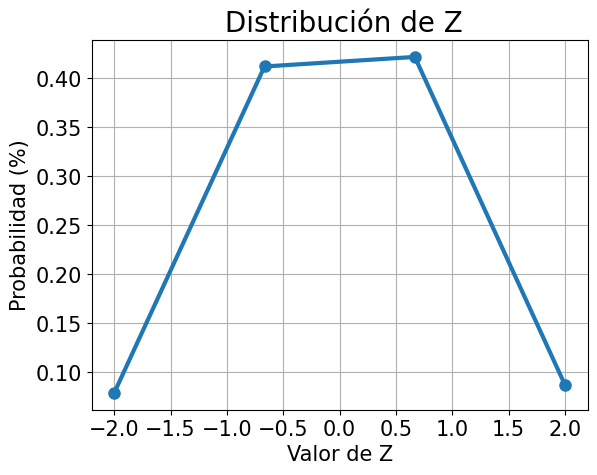

In [8]:
# Graficar los resultados para Z
plt.plot(z_values, p_z, "o-", linewidth=3, markersize=8)
plt.grid()
plt.xlabel("Valor de Z", size=15)
plt.ylabel("Probabilidad (%)", size=15)
plt.title(" Distribución de Z", size=20)
plt.xticks(size=15)
plt.yticks(size=15)
plt.show()

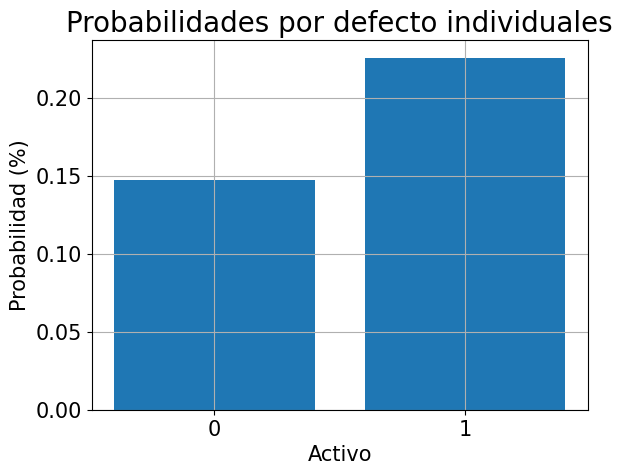

In [9]:
# Graficar los resultados para las probabilidades por defecto
plt.bar(range(K), p_default)
plt.xlabel("Activo", size=15)
plt.ylabel("Probabilidad (%)", size=15)
plt.title("Probabilidades por defecto individuales", size=20)
plt.xticks(range(K), size=15)
plt.yticks(size=15)
plt.grid()
plt.show()

# Pérdida esperada

Para estimar la pérdida esperada, primero aplicamos un operador de suma ponderada para sumar todas las pérdidas individuales:
$$ \mathcal{S}: |x_1, ..., x_K \rangle_K |0\rangle_{n_S} \mapsto |x_1, ..., x_K \rangle_K |\lambda_1x_1 + ... + \lambda_K x_K\rangle_{n_S}. $$ 
El número necesario de qubits para representar el resultado viene dado por
$$ n_s = \lfloor \log_2( \lambda_1 + ... + \lambda_K ) \rfloor + 1. $$
Una vez tenemos la distribución de la pérdida total en un registro cuántico, podemos usar las técnicas descritas por [Woerner2019] para mapear la pérdida total $L \in \{0, ..., 2^{n_s}-1\}$ a la amplitud de un qubit mediante el operador
$$ | L \rangle_{n_s}|0\rangle \mapsto
| L \rangle_{n_s} \left( \sqrt{1 - L/(2^{n_s}-1)}|0\rangle + \sqrt{L/(2^{n_s}-1)}|1\rangle \right), $$
que nos permite llevar a cabo Amplitude Estimation para evaluar la pérdida esperada.

In [10]:
#Añadir Z qubits con peso/pérdida 0
from qiskit.circuit.library import WeightedAdder
agg = WeightedAdder(n_z + K, [0] * n_z + lgd)

In [11]:
from qiskit.circuit.library import LinearAmplitudeFunction

#Deninimos la función lineal objetivo
breakpoints = [0]
slopes = [1]
offsets = [0]
f_min = 0
f_max = sum(lgd)
c_approx = 0.25

objective = LinearAmplitudeFunction(
    agg.num_sum_qubits,
    slope = slopes,
    offset = offsets,
    #Valor máximo que puede alcanzar el registro de qubits (no siempre se alcanzará)
    domain = (0, 2**agg.num_sum_qubits - 1),
    image = (f_min, f_max),
    rescaling_factor = c_approx,
    breakpoints = breakpoints,
)

Creamos el circuito que prepara el estado:

In [13]:
#Denimos los registros por conveniencia y para facilitar la lectura
qr_state = QuantumRegister(u.num_qubits, "state")
qr_sum = QuantumRegister(agg.num_sum_qubits, "sum")
qr_carry = QuantumRegister(agg.num_carry_qubits, "carry")
qr_obj = QuantumRegister(1, "Objective")

#Definimos el circuito
state_preparation = QuantumCircuit(qr_state, qr_obj, qr_sum, qr_carry, name = "A")

#Cargamos la valiable aleatoria
state_preparation.append(u.to_gate(), qr_state)

#agregado
state_preparation.append(agg.to_gate(), qr_state[:] + qr_sum[:] + qr_carry[:])

#Función lineal objetivo
state_preparation.append(objective.to_gate(), qr_sum[:] + qr_obj[:])

#Deshacemos el agregado
state_preparation.append(agg.to_gate().inverse(), qr_state[:] + qr_sum[:] + qr_carry[:])

#Dibujamos el circuito
state_preparation.draw()

┌───────┐┌────────┐      ┌───────────┐
  state_0: ┤0      ├┤0       ├──────┤0          ├
           │       ││        │      │           │
  state_1: ┤1      ├┤1       ├──────┤1          ├
           │  P(X) ││        │      │           │
  state_2: ┤2      ├┤2       ├──────┤2          ├
           │       ││        │      │           │
  state_3: ┤3      ├┤3       ├──────┤3          ├
           └───────┘│  adder │┌────┐│  adder_dg │
Objective: ─────────┤        ├┤2   ├┤           ├
                    │        ││    ││           │
    sum_0: ─────────┤4       ├┤0 F ├┤4          ├
                    │        ││    ││           │
    sum_1: ─────────┤5       ├┤1   ├┤5          ├
                    │        │└────┘│           │
    carry: ─────────┤6       ├──────┤6          ├
                    └────────┘      └───────────┘

Antes de utilizar QAE para estimar la pérdida esperada, comprobamos el circuito representando la función objetivo simulando el circuito y analizando la probabilidad de encontrar el qubit objetivo en el estado $\ket{1}$, es decir, el valor al que el QAE aproximará eventualmente.

In [14]:
from qiskit.primitives import StatevectorSampler
state_preparation_measure = state_preparation.measure_all(inplace = False) 
sampler= StatevectorSampler(default_shots = 100, seed = 75)
job = sampler.run([state_preparation_measure])
result = job.result()[0]
counts = result.data.meas.get_counts()
shots = 100
binary_probabilities = {state: count / shots for state, count in counts.items()}

In [15]:
#Evaluamos el resultado
value = 0
for i, prob in binary_probabilities.items():
    if prob > 1e-6 and i[-(len(qr_state) + 1) :][0] == "1":
        value += prob
print("Pérdida esperada exacta:   %.4f" % expected_loss)
print("Valor del operador exacto:  %.4f" % value)
print("valor del operador mapeado: %.4f" % objective.post_processing(value))

Pérdida esperada exacta:   0.5986
Valor del operador exacto:  0.4700
valor del operador mapeado: 1.2708


Ahora corremos QAE para estimar la pérdida esperada con una rapidez cuadráticamente mayor que la simulación de Monte Carlo clásica.

In [16]:

#Definios la precisión e intervalo de confianza objetivos
epsilon = 0.01
alpha = 0.05

problem = EstimationProblem(
    state_preparation = state_preparation,
    objective_qubits = [len(qr_state)],
    post_processing = objective.post_processing,
)

#Construimos Amplitude Estimation
ae = IterativeAmplitudeEstimation(
    epsilon_target = epsilon, alpha = alpha, sampler = sampler
)
result = ae.estimate(problem)

#Damos los resultados
conf_int = np.array(result.confidence_interval_processed)
print("Valor exacto:    \t%.4f" % expected_loss)
print("Valor estimado:\t%.4f" % result.estimation_processed)
print("Intervalo de confianza: \t[%.4f, %.4f]" % tuple(conf_int))

Valor exacto:    	0.5986
Valor estimado:	0.6962
Intervalo de confianza: 	[0.6273, 0.7650]


# Función de distribución acumulada

En vez de la pérdida esperada (que puede ser estimada de manera eficiente utilizando técnicas clásicas), estimamos ahora la función de distribución acumulada (CDF) de la pérdida. Clásicamente, esto supone bien evaluar todas las posibles combinaciones de activos o muchas muestras para simulaciones en Monte Carlo. Los algoritmos basados en QAE tienen el potencial de acelerar de manera significativa este análisis en el futuro.

Para estimar la CDF, es decir, la probabilidad $ \mathbb{P}[L \leq x] $, volvemos a aplicar $\mathcal{S}$ para computar la pérdida total, y después aplicar un comparador para un valor dado $x$ que actua como
$$ \begin{split} \mathcal{C}: |L\rangle_n|0> \mapsto
\begin{cases}
|L\rangle_n|1> & \text{if}\quad L \leq x \\
|L\rangle_n|0> & \text{if}\quad L > x.
\end{cases}\end{split} $$
El estado resultante puede escribirse como
$$\sum_{L = 0}^{x} \sqrt{p_{L}}|L\rangle_{n_s}|1\rangle +
\sum_{L = x+1}^{2^{n_s}-1} \sqrt{p_{L}}|L\rangle_{n_s}|0\rangle, $$

donde podemos asumir directamente las pérdidas sumadas y sus correspondientes probabilidades en vez de presentar detalles del modelo de incertidumbre.

La CDF($x$) es lo mismo que la probabilidad de medir el estado $\ket{1}$ en el qubit objetivo y se puede aplicar directamente QAE para estimarlo. 

In [17]:
# Definimos x para estimar la CDF
x_eval = 2

comparator = IntegerComparator(agg.num_sum_qubits, x_eval + 1, geq=False)
comparator.draw()

┌──────────────┐
state_0: ┤0             ├
         │              │
state_1: ┤1             ├
         │  circuit-865 │
compare: ┤2             ├
         │              │
    a17: ┤3             ├
         └──────────────┘

In [18]:
def get_cdf_circuit(x_eval):
    #Definimos registros por conveniencia
    qr_state = QuantumRegister(u.num_qubits, "state")
    qr_sum = QuantumRegister(agg.num_sum_qubits, "sum")
    qr_carry = QuantumRegister(agg.num_carry_qubits, "carry")
    qr_obj = QuantumRegister(1, "objective")
    qr_compare = QuantumRegister(1, "compare")

    #Definimos el circuito
    state_preparation = QuantumCircuit(qr_state, qr_obj, qr_sum, qr_carry, name="A")

    # Cargamos la variable aleatoria
    state_preparation.append(u, qr_state)

    # aggregate
    state_preparation.append(agg, qr_state[:] + qr_sum[:] + qr_carry[:])

    # comparator objective function
    comparator = IntegerComparator(agg.num_sum_qubits, x_eval + 1, geq=False)
    state_preparation.append(comparator, qr_sum[:] + qr_obj[:] + qr_carry[:])

    # uncompute aggregation
    state_preparation.append(agg.inverse(), qr_state[:] + qr_sum[:] + qr_carry[:])

    return state_preparation
state_preparation = get_cdf_circuit(x_eval)

De nuevo, primero utilizamos simulación cuántica para validar el circuito

In [19]:
state_preparation.draw()

┌───────┐┌────────┐        ┌───────────┐
  state_0: ┤0      ├┤0       ├────────┤0          ├
           │       ││        │        │           │
  state_1: ┤1      ├┤1       ├────────┤1          ├
           │  P(X) ││        │        │           │
  state_2: ┤2      ├┤2       ├────────┤2          ├
           │       ││        │        │           │
  state_3: ┤3      ├┤3       ├────────┤3          ├
           └───────┘│  adder │┌──────┐│  adder_dg │
objective: ─────────┤        ├┤2     ├┤           ├
                    │        ││      ││           │
    sum_0: ─────────┤4       ├┤0     ├┤4          ├
                    │        ││  cmp ││           │
    sum_1: ─────────┤5       ├┤1     ├┤5          ├
                    │        ││      ││           │
    carry: ─────────┤6       ├┤3     ├┤6          ├
                    └────────┘└──────┘└───────────┘

In [20]:
state_preparation_measure = state_preparation.measure_all(inplace = False) 
sampler= StatevectorSampler(default_shots = 100, seed = 75)
job = sampler.run([state_preparation_measure])
result = job.result()[0]
counts = result.data.meas.get_counts()
shots = 100
binary_probabilities = {state: count / shots for state, count in counts.items()}

In [21]:
#Evaluamos el resultado
var_prob = 0
for i, prob in binary_probabilities.items():
    if prob > 1e-6 and i[-(len(qr_state) + 1) :][0] == "1":
        var_prob += prob

print("Operador  CDF(%s)" % x_eval + " = %.4f" % var_prob)
print("Exacta    CDF(%s)" % x_eval + " = %.4f" % cdf[x_eval])

Operador  CDF(2) = 0.9600
Exacta    CDF(2) = 0.9619


Corremos ahora QAE para estimar la CDF dado $x$

In [22]:
#Definimos la precisión y el nivel de confianza buscados
epsilon = 0.01
alpha = 0.05

problem = EstimationProblem(state_preparation=state_preparation, objective_qubits=[len(qr_state)])
# construct amplitude estimation
ae_cdf = IterativeAmplitudeEstimation(
    epsilon_target=epsilon, alpha=alpha, sampler=sampler
)
result_cdf = ae_cdf.estimate(problem)

# print results
conf_int = np.array(result_cdf.confidence_interval)
print("Valor exacto:    \t%.4f" % cdf[x_eval])
print("Valor estimado:  \t%.4f" % result_cdf.estimation)
print("Intervalo de confianza:\t[%.4f, %.4f]" % tuple(conf_int))

Valor exacto:    	0.9619
Valor estimado:  	0.9592
Intervalo de confianza:	[0.9582, 0.9601]


# Value at Risk

A continuación, utilizamos una búsqueda por bisección y QAE para evaluar de manera eficiente la CDF para estimar el Value at Risk.

In [23]:
def run_ae_for_cdf(x_eval, epsilon=0.01, alpha = 0.05):
    #Construimos el Amplitude Estimation
    state_preparation = get_cdf_circuit(x_eval)
    problem = EstimationProblem(
        state_preparation = state_preparation, objective_qubits= [len(qr_state)]
    )
    ae_var = IterativeAmplitudeEstimation(
        epsilon_target = epsilon, alpha = alpha, sampler = sampler
    )
    result_var = ae_var.estimate(problem)

    return result_var.estimation

In [24]:
def bisection_search(
    objective, target_value, low_level, high_level, low_value = None, high_value = None 
):
    """
    Determina el nivel más bajo tal que el valor objetivo es mayor que el objetivo
    :param objetive: función objetivo
    :param target: valor objetivo
    :param low_level: valor más pequeño a ser considerado
    :param high_level: valor más grande a ser considerado
    :param low_value: valor del nivel más bajo (será evaluado si se deja como None)
    :param high_value: valor del nivel más alto (será evaluado si se deja como None)
    :return: un directorio con nivel, valor y numero de evaluación
    """

    #Comprobar si se dan low y high values y evaluarlos
    print("--------------------------------------------------------------------")
    print("Comenzar la búsqueda por bisección para el valor objetivo %.3f" % target_value)
    print("--------------------------------------------------------------------")

    num_eval = 0
    if low_value is None:
        low_value = objective(low_level)
        num_eval += 1
    if high_value is None:
        high_value = objective(high_level)
        num_eval += 1

    #Comprobar si low_value satisface la condición:
    if low_value > target_value:
        return {
            "nivel": low_level,
            "valor": low_value,
            "num_eval": num_eval,
            "Comentario": "se devuelve el valor bajo",
        }
    elif low_value == target_value:
        return{
            "nivel": low_level,
            "valor": low_value,
            "num_eval": num_eval,
            "Comentario": "Éxito",
        }
    #Comprobar si high_level está por encima del objetivo
    if high_value < target_value:
        return {
            "nivel": high_level,
            "valor": high_value,
            "num_eval": num_eval,
            "comentario": "se devuelve el valor bajo",
        }
    elif high_value == target_value:
        return {
            "nivel": high_level,
            "valor": high_value,
            "num_eval": num_eval,
            "comentario": "Éxito",
        }

    # perform bisection search until
    print("low_level    low_value    nivel    valor    high_level    high_value")
    print("--------------------------------------------------------------------")
    while high_level - low_level > 1:

        level = int(np.round((high_level + low_level) / 2.0))
        num_eval += 1
        value = objective(level)

        print(
            "%2d           %.3f        %2d       %.3f    %2d            %.3f"
            % (low_level, low_value, level, value, high_level, high_value)
        )

        if value >= target_value:
            high_level = level
            high_value = value
        else:
            low_level = level
            low_value = value

    # return high value after bisection search
    print("--------------------------------------------------------------------")
    print("Terminada la búsqueda por bisección")
    print("--------------------------------------------------------------------")
    return {"nivel": high_level, "valor": high_value, "num_eval": num_eval, "Comentario": "success"}

In [25]:
#Corremos la bisección para determinar el VaR
objective = lambda x: run_ae_for_cdf(x)
bisection_result = bisection_search(
    objective, 1 - alpha, min(losses) - 1, max(losses), low_value = 0, high_value = 1
)
var = bisection_result["nivel"]

--------------------------------------------------------------------
Comenzar la búsqueda por bisección para el valor objetivo 0.950
--------------------------------------------------------------------
low_level    low_value    nivel    valor    high_level    high_value
--------------------------------------------------------------------
-1           0.000         1       0.752     3            1.000
 1           0.752         2       0.959     3            1.000
--------------------------------------------------------------------
Terminada la búsqueda por bisección
--------------------------------------------------------------------


In [26]:
print("VaR estimado: %2d" % var)
print("VaR exacto:     %2d" % exact_var)
print("Probabilidad estimada:    %.3f" % bisection_result["valor"])
print("Probabilidad exacta:        %.3f" % cdf[exact_var])

VaR estimado:  2
VaR exacto:      2
Probabilidad estimada:    0.959
Probabilidad exacta:        0.962


# Conditional Value at Risk

Por último, programamos el CVaR, es decir, el valor esperado de la pérdida cuando es mayor o igual que el VaR. Para ello, evaluamos una función objetivo lineal $f(L)$, dependiente de la pérdida total $L$, dada por 
$$ \begin{split}f(L) = \begin{cases}
0 & \text{if}\quad L \leq VaR \\
L & \text{if}\quad L > VaR.
\end{cases}\end{split} $$
Para normalizarla, tenemos que dividirla entre el valor esperado de la probabilidad del VaR, es decir $ \mathbb{P}[L \leq VaR] $

In [27]:
#Definimos el objetivo lineal
breakpoints = [0, var]
slopes = [0, 1]
offsets = [0, 0] #Restamos el VaR y lo añadimos depués para estimar
f_min = 0
f_max = 3 - var
c_approx = 0.25

cvar_objective = LinearAmplitudeFunction(
    agg.num_sum_qubits,
    slopes,
    offsets,
    domain = (0, 2**agg.num_sum_qubits -1), 
    image = (f_min, f_max),
    rescaling_factor = c_approx,
    breakpoints = breakpoints
)

cvar_objective.draw()

┌────┐
q84_0: ┤0   ├
       │    │
q84_1: ┤1   ├
       │    │
  q85: ┤2 F ├
       │    │
a86_0: ┤3   ├
       │    │
a86_1: ┤4   ├
       └────┘

In [28]:
#Definimos los registros de nuevo
# define the registers for convenience and readability
qr_state = QuantumRegister(u.num_qubits, "state")
qr_sum = QuantumRegister(agg.num_sum_qubits, "sum")
qr_carry = QuantumRegister(agg.num_carry_qubits, "carry")
qr_obj = QuantumRegister(1, "objective")
qr_work = QuantumRegister(cvar_objective.num_ancillas - len(qr_carry), "work")

# define the circuit
state_preparation = QuantumCircuit(qr_state, qr_obj, qr_sum, qr_carry, qr_work, name="A")

# load the random variable
state_preparation.append(u, qr_state)

# aggregate
state_preparation.append(agg, qr_state[:] + qr_sum[:] + qr_carry[:])

# linear objective function
state_preparation.append(cvar_objective, qr_sum[:] + qr_obj[:] + qr_carry[:] + qr_work[:])

# uncompute aggregation
state_preparation.append(agg.inverse(), qr_state[:] + qr_sum[:] + qr_carry[:])

state_preparation.draw()

┌───────┐┌────────┐      ┌───────────┐
  state_0: ┤0      ├┤0       ├──────┤0          ├
           │       ││        │      │           │
  state_1: ┤1      ├┤1       ├──────┤1          ├
           │  P(X) ││        │      │           │
  state_2: ┤2      ├┤2       ├──────┤2          ├
           │       ││        │      │           │
  state_3: ┤3      ├┤3       ├──────┤3          ├
           └───────┘│  adder │┌────┐│  adder_dg │
objective: ─────────┤        ├┤2   ├┤           ├
                    │        ││    ││           │
    sum_0: ─────────┤4       ├┤0   ├┤4          ├
                    │        ││    ││           │
    sum_1: ─────────┤5       ├┤1 F ├┤5          ├
                    │        ││    ││           │
    carry: ─────────┤6       ├┤3   ├┤6          ├
                    └────────┘│    │└───────────┘
     work: ───────────────────┤4   ├─────────────
                              └────┘

In [29]:
state_preparation_measure = state_preparation.measure_all(inplace = False) 
sampler= StatevectorSampler(default_shots = 100, seed = 75)
job = sampler.run([state_preparation_measure])
result = job.result()[0]
counts = result.data.meas.get_counts()
shots = 100
binary_probabilities = {state: count / shots for state, count in counts.items()}

In [30]:
#Evaluamos el resultado
value = 0
for i, prob in binary_probabilities.items():
    if prob > 1e-6 and i[-(len(qr_state) + 1)] == "1":
        value += prob

#Normalizamos y añadimos el VaR para estimar
value = cvar_objective.post_processing(value)
d = 1.0 - bisection_result["valor"]
v = value / d if d != 0 else 0
normalized_value = v + var
print("CVaR estimado: %.4f" % normalized_value)
print("CVaR exacto:     %.4f" % exact_cvar)

CVaR estimado: 9.8785
CVaR exacto:     3.0000


Corremos ahora QAE para estimar CVaR

In [31]:
#Definimos la precisión y el nivel de confianza buscado
epsilon = 0.01
alpha = 0.05

problem = EstimationProblem(
    state_preparation = state_preparation,
    objective_qubits = [len(qr_state)],
    post_processing = cvar_objective.post_processing,
)

#Construimos Amplitude Estimation
ae_cvar = IterativeAmplitudeEstimation(
    epsilon_target = epsilon, alpha = alpha, sampler = sampler
)
result_cvar = ae_cvar.estimate(problem)

In [32]:
# Escribimos los resultados
d = 1.0 - bisection_result["valor"]
v = result_cvar.estimation_processed / d if d != 0 else 0
print("CVaR exacto:    \t%.4f" % exact_cvar)
print("CVaR estimado:\t%.4f" % (v + var))

CVaR exacto:    	3.0000
CVaR estimado:	3.3234
